In [8]:
# data sets
from tdc.utils import get_reaction_type

# rdkit things
from rdkit import Chem
from rdkit.Chem import GetPeriodicTable
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw
from rdkit.Chem.Draw import ReactionToImage
from rdkit.Chem.Draw import MolToImage
from rdkit.Chem import AllChem

# standard libraries
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time

# machine learning libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GINEConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

# used to explore hyperparameter space
from sklearn.model_selection import RandomizedSearchCV # took way too long
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

from sklearn.base import BaseEstimator
from scipy.stats import uniform

### (1) Retrieve the cleaned data from data_exploration.ipynb to use in our model. Structure it to use in model.

In [9]:
alchemy_elements = {'C', 'Cl', 'F', 'H', 'N', 'O', 'S'}
molecule_types_df = pd.read_csv("/Users/joshuahoang/Documents/Chem-C242-Final-Project-Organic-Reactions/Collected Data/Alchemy-v20191129/final_version_with_smiles.csv")
reaction_types_df = pd.read_csv("/Users/joshuahoang/Documents/Chem-C242-Final-Project-Organic-Reactions/Collected Data/uspto_50k_processed.csv")

display(molecule_types_df)
display(reaction_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles
0,2859833,9,0.226164,0.000067,0.300531,-352.128828,-0.236722,-352.076085,99.201621,-352.088194,-352.075141,0.063809,0.180558,1919.249225,CC#CC[C@H](C)CCC
1,3148292,9,0.180782,0.000058,0.293098,-386.820766,-0.241536,-386.774917,84.670738,-386.784878,-386.773973,0.051562,1.302656,1420.242859,C#CC[C@@H]1CO[C@@H]1CC
2,3607838,9,0.205922,0.000057,0.307544,-388.062328,-0.224965,-388.018758,86.198178,-388.028208,-388.017814,0.082579,1.284923,1257.238492,CC[C@H]1[C@H]2CCO[C@]21C
3,9540153,11,0.160845,0.000056,0.195923,-515.046508,-0.203538,-515.001198,95.801267,-515.010568,-515.000254,-0.007615,4.074910,1600.220066,COc1nccc2c1OCC2
4,340363,10,0.177712,0.000057,0.254495,-403.843164,-0.248943,-403.800346,95.147725,-403.809426,-403.799402,0.005552,4.111533,1442.171110,CC1=CC[C@H]2C[C@@H]2[C@H]1C#N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202574,9581016,10,0.120222,0.000051,0.179768,-450.915828,-0.244325,-450.872449,88.581216,-450.881390,-450.871505,-0.064557,6.434535,1541.115465,CNc1cc(C#N)ncn1
202575,9706527,10,0.130179,0.000053,0.189401,-438.632624,-0.231340,-438.589755,96.102362,-438.598674,-438.588811,-0.041938,0.338522,1628.839361,C#Cc1ccnc(OC)c1
202576,9760179,10,0.119919,0.000051,0.163827,-450.920199,-0.232783,-450.875248,89.074794,-450.884399,-450.874304,-0.068956,4.337358,1497.024559,CNc1nccc(C#N)n1
202577,9845175,10,0.119740,0.000050,0.191354,-454.722866,-0.251374,-454.680504,89.026059,-454.689065,-454.679560,-0.060020,5.263580,1611.219983,COc1cncc(C#N)c1


,reactant,product,category
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9
...,...,...,...
35111,COC(=O)c1ccc(C(=O)OCc2ccccc2)cc1F,COC(=O)c1ccc(C(=O)O)cc1F,6
35112,C=CCOC(=O)N1CCc2nnc(NN)cc2C1.CC(C)=O,C=CCOC(=O)N1CCc2nnc(NN=C(C)C)cc2C1,1
35113,FC1(F)CCNC1.O=C(O)c1ccncc1NC(=O)c1nc(C2CC2)ccc...,O=C(Nc1cnccc1C(=O)N1CCC(F)(F)C1)c1nc(C2CC2)ccc...,2
35114,CC(=O)Cl.CC(C)(C)OC(=O)NCCO,CC(=O)OCCNC(=O)OC(C)(C)C,2


Pipeline

(a) The GNN will take each molecule as a pooling of the atoms as nodes and the bonds as edges and lets each atom update its features by aggreating from its neighbors. 

(b) After this messaging, pool atoms to molecule to predict the target features that will be used in the decision tree for the reaction type. 

     - 12/15 columns are physics-relevent
     - 9/12 of the physics-relevent ones do not have too bad overlap

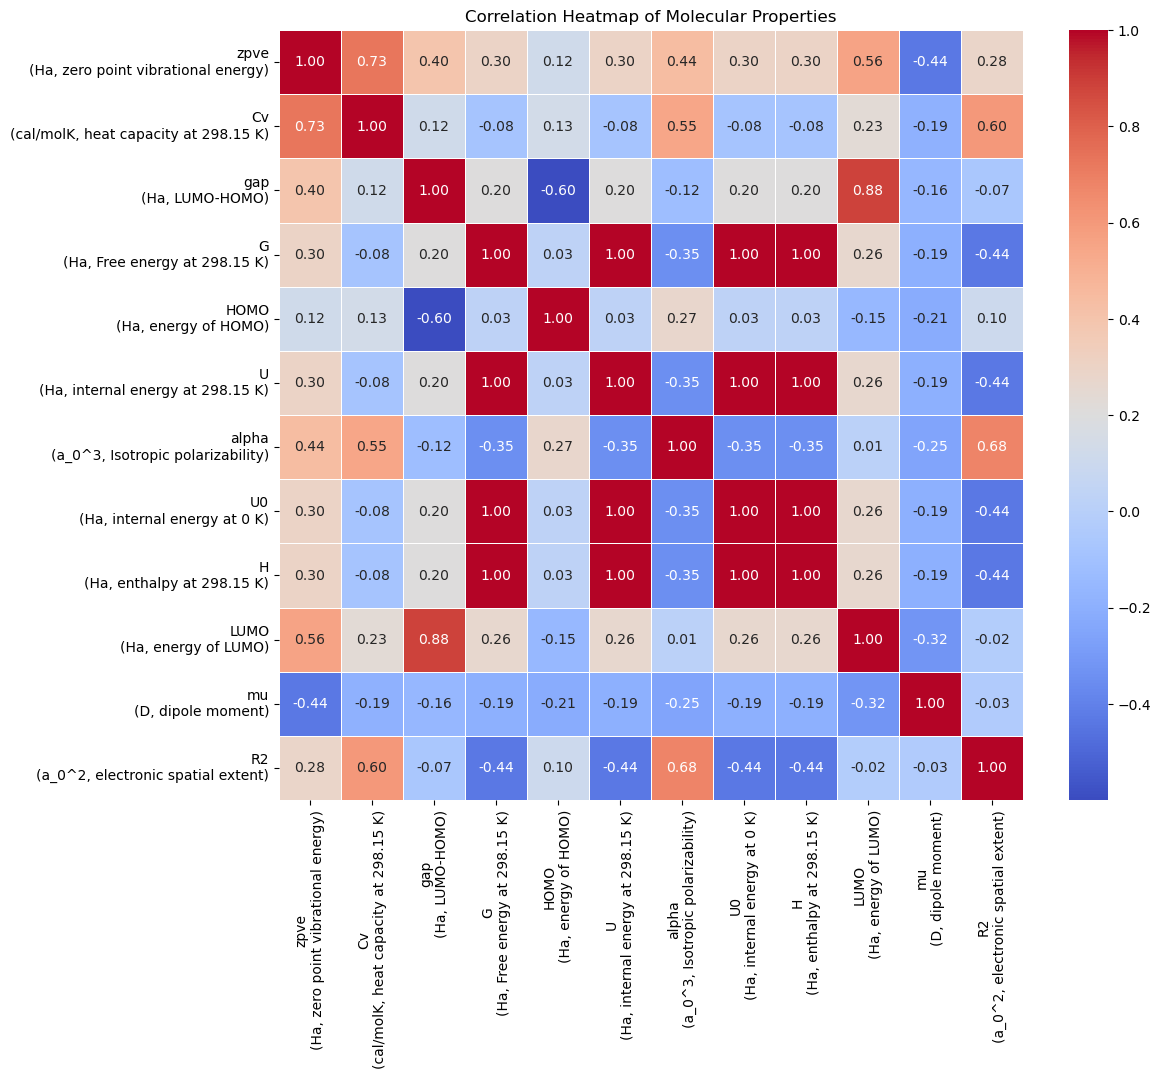

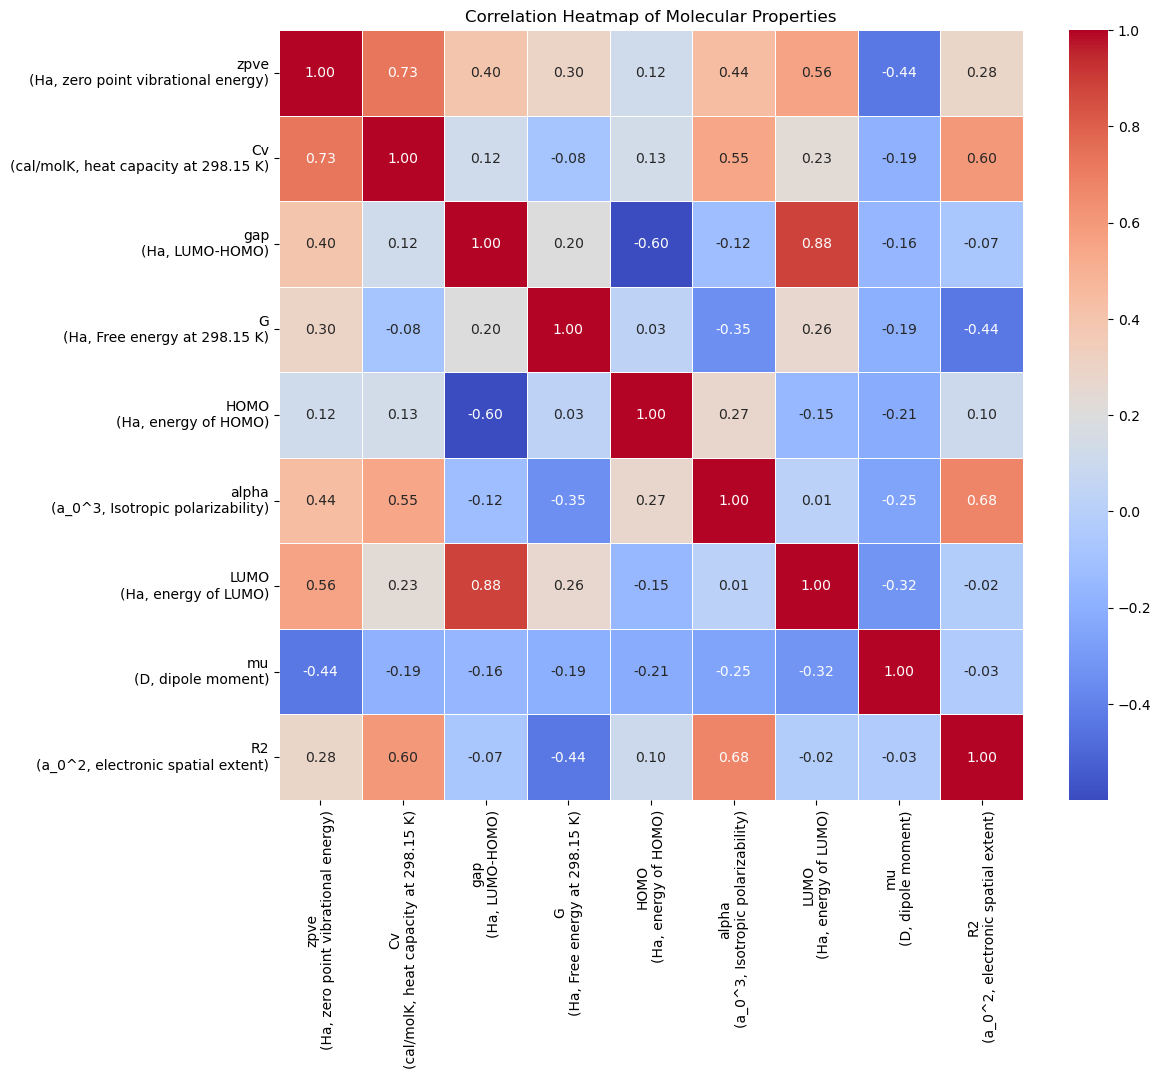

In [10]:
def plot_heatmap(df):
    plt.figure(figsize=(12,10))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Molecular Properties")
    plt.show()

# 12/15 that are physics-relevent
molecule_targets_df = molecule_types_df.drop(columns=['smiles', 'gdb_idx', 'atom number'])
plot_heatmap(molecule_targets_df)

# G, U, U0, H: G = U + PV - TS = H - TS, so we only need 1 -> keep G
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'U\n(Ha, internal energy at 298.15 K)',
    'U0\n(Ha, internal energy at 0 K)', 
    'H\n(Ha, enthalpy at 298.15 K)', 
])
plot_heatmap(molecule_targets_df)

### (2) Focus on making the GNN with the alchemy DFT data. 

Turn all the data into a graph structure. We choose the features that only the organic chemists care for which is geometrty, resonance, if it is in a ring, etc. Aromaticity is already in bond order. 

In [ ]:
def atom_feature_vector(atom):
    return [
        atom.GetAtomicNum(),          # atomic number, e.g. 6=C, 7=N, 8=O, 17=Cl
        atom.GetDegree(),             # number of directly bonded neighbors
        atom.GetTotalNumHs(),         # total attached hydrogens (implicit + explicit)
        atom.GetFormalCharge(),       # formal charge on the atom
        int(atom.GetIsAromatic()),    # aromatic atom flag: 1 if aromatic else 0
        int(atom.IsInRing()),         # ring membership flag: 1 if atom is in a ring else 0
        int(atom.GetHybridization()), # hybridization enum value (sp, sp2, sp3, etc.)
    ]


def bond_feature_vector(bond, pos):

    i = bond.GetBeginAtomIdx()
    j = bond.GetEndAtomIdx()
    distance = torch.norm(pos[i] - pos[j]).item()  # now uses coordinates pulled from the Alchemy sdf file

    return [
        float(bond.GetBondTypeAsDouble()), # bond order: 1.0=single,2.0=double,3.0=triple,1.5=aromatic
        # int(bond.GetIsAromatic()),       # redundant: aromatic bond already encoded by bond order = 1.5
        int(bond.IsInRing()),              # ring membership flag for bond
        int(bond.GetStereo()),             # stereochemistry enum for bond geometry
        distance,                          # bond distance, CANNOT add angle in GINEConv
    ]


def smiles_to_graph(smi, coords, y):
    """
    Convert a SMILES string + Alchemy coordinates to a PyTorch Geometric Data object.
    Nodes represent atoms, and edges represent bonds.
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None

    # coordinates are now taken directly from the Alchemy sdf file, not approximated from RDKit embedding
    pos = torch.tensor(coords, dtype=torch.float)

    # sanity check: coordinates must align with atom order in the SMILES-derived RDKit molecule
    if pos.shape[0] != mol.GetNumAtoms():
        return None

    # atom features
    atom_features = [atom_feature_vector(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    # edge features
    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_feature_vector(bond, pos)

        edge_index.append((i, j))
        edge_attr.append(bf)

        edge_index.append((j, i))
        edge_attr.append(bf)
        # undirected graph, both directions

    # convert to tensor
    if len(edge_index) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 4), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # targets
    y = torch.tensor(y, dtype=torch.float).view(1, -1)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        pos=pos,   # 3D coordinates from the Alchemy sdf file
        y=y
    )

Convert all the data into graphs to work in the GNN. Then, normalize the molecule features.

In [14]:
graph_dataset = []
for idx, row in molecule_types_df.iterrows():
    graph = smiles_to_graph(
        row['smiles'], 
        row[molecule_targets_df.columns].astype(float).values
    )
    if graph is not None:
        graph_dataset.append(graph)

g = graph_dataset[0]
print(g.x.shape)            # [num_atoms, 1]
print(g.edge_index.shape)   # [2, num_edges]
print(g.y.shape)            # should be 9
# okay great nothing exploded

all_y = torch.stack([g.y for g in graph_dataset])
y_mean = all_y.mean(dim = 0)
y_std = all_y.std(dim = 0).clamp_min(1e-8) # avoid div by 0 error

for g in graph_dataset: 
    g.y = (g.y - y_mean) / y_std

[05:46:09] UFFTYPER: Unrecognized atom type: S_5+6 (6)
[05:47:02] UFFTYPER: Unrecognized atom type: S_5+6 (3)
[05:51:00] UFFTYPER: Unrecognized atom type: S_6+6 (2)


KeyboardInterrupt: 

In [ ]:
# the data from above took a while make because of the forcefields, so save it so 
# we don't need to rerun

Now use an architechture that does not ignore bond or edges like GCNConv and instead GINEConv. 
 - GINEConv: Does not update edge features. 
 - Design choice: But the edge features here are bond order, ring flag, and stereo, so which are static and so we don't really care or need to update them. GINEConv is best, but if we do want our own MPNN, we can remove the edge update!

In [ ]:
class GNN(torch.nn.Module): 
    # screw around with the hidden_dim to get better regression statistic
    # number of y predictions is out_dim in case of future change
    def __init__(self, in_channels, edge_dim, hidden_dim, out_dim = molecule_targets_df.shape[1], dropout=0.2): 
        super().__init__()

        # node features into hidden space
        self.node_encoder = nn.Linear(in_channels, hidden_dim)

        # edge features into hidden space
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        # GINE blocks for convolution, with edge features 
        self.conv1 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )
        self.conv2 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )
        self.conv3 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # encode raw node and edge features into hidden space
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)
    
        # first graph convolution block
        x_res = x # skip connection
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # second graph convolution block
        x_res = x # skip connection
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # third graph convolution block
        x_res = x # skip connection
        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)
        x = x + x_res # skip connection
    
        # pool from atom space to molecule space
        x = global_mean_pool(x, batch)
    
        # readout MLP
        x_res = x # skip connection
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
        x = self.lin2(x)
        return x # at some point put skip connections maybe faster convergence idk
        
class Trainer: 
    def __init__(
        self,
        model,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        loss_type="smoothl1",   # "mse" or "smoothl1"
        beta=0.5, # for smooth l1; 1-2 is more MSE like, 0.5 is more L1 like
        device="cpu"
    ):
        super().__init__()

        self.model = model.to(device)
        self.device = device
        self.optimizer = optimizer(self.model.parameters(), lr=lr)

        if loss_type == "mse": self.loss_function = torch.nn.MSELoss()
        elif loss_type == "smoothl1": self.loss_function = torch.nn.SmoothL1Loss(beta=beta)
        else: raise ValueError("loss_type must be 'mse' or 'smoothl1'")

    def train_one_epoch(self, loader): 
        self.model.train() # training 'mode' as per tutorial 
        total_loss = 0.0

        for batch in loader: 
            batch = batch.to(self.device)
            self.optimizer.zero_grad() # pas grad not needed as we evaluate

            # mps needs contiguous tensors for smooth l1, so reshape and make contiguous
            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            target = batch.y
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()

            loss = self.loss_function(pred, target)
            loss.backward() # find the gradients
            self.optimizer.step() # update the weights
            total_loss += loss.item()
        
        return total_loss / len(loader) # average loss per batch 
    
    # used for testing phase
    @torch.no_grad()
    def evaluate(self, loader): 
        self.model.eval()
        total_loss = 0.0
        all_preds = []  # Collect all predictions
        all_targets = []  # Collect all targets

        for batch in loader: 
            batch = batch.to(self.device) 

            # mps needs contiguous tensors for smooth l1, so reshape and make contiguous
            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch) 
            target = batch.y
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()

            loss = self.loss_function(pred, target)
            total_loss += loss.item()
            all_preds.append(pred.cpu())  # Store predictions for R² calculation
            all_targets.append(target.cpu())  # Store targets for R² calculation
        
        all_preds = torch.cat(all_preds, dim=0)  # Concatenate all predictions
        all_targets = torch.cat(all_targets, dim=0)  # Concatenate all targets
        
        # Compute average R² across outputs (measure of accuracy for regression)
        ss_res = ((all_preds - all_targets) ** 2).sum(dim=0)  # Sum of squared residuals per output
        ss_tot = ((all_targets - all_targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)        
        r2_per_output = 1 - (ss_res / ss_tot)  # R² per output
        avg_r2 = r2_per_output.mean().item()  # Average R² across all outputs
        
        return total_loss / len(loader), avg_r2
    
    def fit(self, train_loader, val_loader, epochs, show_progress = True): 
        train_losses = []
        val_losses = []
        val_r2s = []  # Track R² history

        best_val = float("inf")
        best_train = None
        best_val_r2 = -float("inf")  # Track best R²

        for epoch in range(1, epochs +1): 
            train_loss = self.train_one_epoch(train_loader)
            val_loss, val_r2 = self.evaluate(val_loader)  # Now returns loss and R²

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            val_r2s.append(val_r2)  # Append R² for this epoch

            if val_loss < best_val: 
                best_val = val_loss
                best_train = train_loss
                best_val_r2 = val_r2  # Update best R²

            if show_progress: 
                print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}, r2={val_r2:.4f}")  # Include R² in progress

        return {

            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_r2s": val_r2s,  # Include R² history

            "best_train_loss": best_train,
            "best_val_loss": best_val,
            "best_val_r2": best_val_r2  # Include best R²

        }
    

def run_single_split(
        model_class,
        train_graphs,
        val_graphs,
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        show_progress=False
):
    """
    Train one model on one train/validation split.
    Returns metrics and the trained model.
    """
    # arguments for model class (fixed)
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)

    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    results = trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        show_progress=show_progress
    )

    return {
        "model": trainer.model,
        "best_train_loss": results["best_train_loss"],
        "best_val_loss": results["best_val_loss"],
        "best_val_r2": results["best_val_r2"],
        "train_losses": results["train_losses"],
        "val_losses": results["val_losses"],
        "val_r2s": results["val_r2s"],
    }


# replace accuracy with the R^2 regression statistic
# the hell of hyperparameter tuning and model selection
def KFoldCrossValidation(
    model_class,
    graph_dataset,
    k=3,
    batch_size=32,
    epochs=20,
    hidden_dim=64,
    dropout=0.2,
    lr=1e-3,
    optimizer=torch.optim.Adam,
    loss_type="smoothl1",
    beta=0.5,
    device="cpu",
    early_break=False,
    show_progress=False,
    make_plots=True,
    verbose=True, # print per fold results
    random_state=67
): 
    """
    Run either:
    - k=1: a single train/validation split
    - k>1: k-fold cross validation

    Returns only metrics for evaluation / hyperparameter search.
    Does NOT return a model. (No need.)
    """
    if k == 1:
        indices = list(range(len(graph_dataset)))
        train_idx, val_idx = train_test_split(
            indices, 
            test_size=0.2, 
            random_state=random_state, 
            shuffle=True
        )
        splits = [(train_idx, val_idx)]
    else:
        kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
        splits = kf.split(graph_dataset)

    # contain results for each fold to compute average and std dev
    train_loss_list = []
    val_loss_list = []
    val_r2_list = []  

    all_train_losses = [] 
    all_val_losses = []  
    all_val_r2s = []  

    for fold, (train_idx, val_idx) in enumerate(splits): 

        # split data 
        train_graphs = [graph_dataset[i] for i in train_idx]
        val_graphs = [graph_dataset[i] for i in val_idx]

        # train and evaluate model on this fold
        fold_results = run_single_split(
            model_class=model_class,
            train_graphs=train_graphs,
            val_graphs=val_graphs, # run_single_split expects raw graphs, not loaders
            batch_size=batch_size,
            epochs=epochs,
            hidden_dim=hidden_dim,
            dropout=dropout,
            lr=lr,
            optimizer=optimizer,
            loss_type=loss_type,
            beta=beta,
            device=device,
            show_progress=show_progress
        )

        train_loss_best = fold_results["best_train_loss"]
        val_loss_best = fold_results["best_val_loss"]
        val_r2_best = fold_results["best_val_r2"]

        train_loss_list.append(train_loss_best)
        val_loss_list.append(val_loss_best)
        val_r2_list.append(val_r2_best)  # Append best R² for final averaging

        all_train_losses.append(fold_results["train_losses"])  # Append full train loss history
        all_val_losses.append(fold_results["val_losses"])  # Append full val loss history
        all_val_r2s.append(fold_results["val_r2s"])  # Append full val R² history

        if verbose:
            print(f"\nFold {fold+1}")
            print(f"Best train loss: {train_loss_best:.4f}")
            print(f"Best val loss: {val_loss_best:.4f}")
            print(f"Best val R²: {val_r2_best:.4f}")  # Print R² for this fold

        if early_break: break

    # Compute average losses and R² per epoch across folds
    avg_train_losses = np.mean(np.array(all_train_losses), axis=0)  # Average train loss per epoch
    avg_val_losses = np.mean(np.array(all_val_losses), axis=0)  # Average val loss per epoch
    avg_val_r2s = np.mean(np.array(all_val_r2s), axis=0)  # Average val R² per epoch


    if make_plots:
        plt.figure(figsize=(10, 6))
        plt.plot(avg_train_losses, label='Average Train Loss')
        plt.plot(avg_val_losses, label='Average Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Curves')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.plot(avg_val_r2s, label='Average Validation R²')
        plt.xlabel('Epoch')
        plt.ylabel('R²')
        plt.title('Validation R² Curve')
        plt.legend()
        plt.grid(True)
        plt.show()

    summary = {
        # hyperparameters used
        "hyperparameters": {
            "k": k,
            "batch_size": batch_size,
            "epochs": epochs,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "lr": lr,
            "optimizer": optimizer.__name__ if hasattr(optimizer, "__name__") else str(optimizer),
            "loss_type": loss_type,
            "beta": beta,
            "device": device,
            "random_state": random_state,
        },

        # main metrics for hyperparameter search
        "mean_train_loss": float(np.mean(train_loss_list)),
        "std_train_loss": float(np.std(train_loss_list)),
        "mean_val_loss": float(np.mean(val_loss_list)),
        "std_val_loss": float(np.std(val_loss_list)),
        "mean_val_r2": float(np.mean(val_r2_list)),
        "std_val_r2": float(np.std(val_r2_list)),

        # per-fold metrics
        "train_loss_per_fold": train_loss_list,
        "val_loss_per_fold": val_loss_list,
        "val_r2_per_fold": val_r2_list,

        # average curves
        "avg_train_losses": avg_train_losses,
        "avg_val_losses": avg_val_losses,
        "avg_val_r2s": avg_val_r2s,
    }
    
    if verbose:
        print("\nFinal results:")
        print(f"Train loss: {summary['mean_train_loss']:.4f} ± {summary['std_train_loss']:.4f}")
        print(f"Val loss: {summary['mean_val_loss']:.4f} ± {summary['std_val_loss']:.4f}")
        print(f"Val R²: {summary['mean_val_r2']:.4f} ± {summary['std_val_r2']:.4f}")

    return summary

def train_and_test(
        model_class,
        graph_dataset,
        test_size=0.1,
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        random_state=67,
        show_progress=False,
        verbose=True, 
        make_plots=True,
):
    """
    Used in the final evaluation phase after hyperparameter tuning to train 
    a model on the full training set and evaluate on the test set.
    """
    train_graphs, test_graphs = train_test_split(
        graph_dataset,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )

    # arguments for model class (fixed)
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    train_losses = []

    for epoch in range(1, epochs + 1):
        train_loss = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        if show_progress: print(f"Epoch {epoch}: train={train_loss:.4f}")

    model = trainer.model.to(device)
    model.eval()

    if loss_type == "mse": loss_function = torch.nn.MSELoss()
    elif loss_type == "smoothl1": loss_function = torch.nn.SmoothL1Loss(beta=beta)

    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            target = batch.y.contiguous()
            loss = loss_function(pred, target)
            total_loss += loss.item()
            all_preds.append(pred.cpu())
            all_targets.append(target.cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    ss_res = ((all_preds - all_targets) ** 2).sum(dim=0)
    ss_tot = ((all_targets - all_targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)

    r2_per_output = 1 - (ss_res / ss_tot)
    test_r2 = r2_per_output.mean().item()
    test_loss = total_loss / len(test_loader)

    if make_plots:
       plt.figure()
       plt.plot(train_losses)
       plt.xlabel("Epoch")
       plt.ylabel("Loss")
       plt.title("Training Loss")
       plt.grid()
       plt.show()
       plt.figure()
       plt.scatter(all_targets.flatten().numpy(), all_preds.flatten().numpy(), alpha=0.4)
       plt.xlabel("True")
       plt.ylabel("Predicted")
       plt.title("Predicted vs True")
       plt.grid()
       plt.show()

    if verbose:
        print(f"Test R²: {test_r2:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

    return {
        "model": model,
        "test_r2": test_r2,
        "test_loss": test_loss,
        "test_r2_per_output": r2_per_output
    }

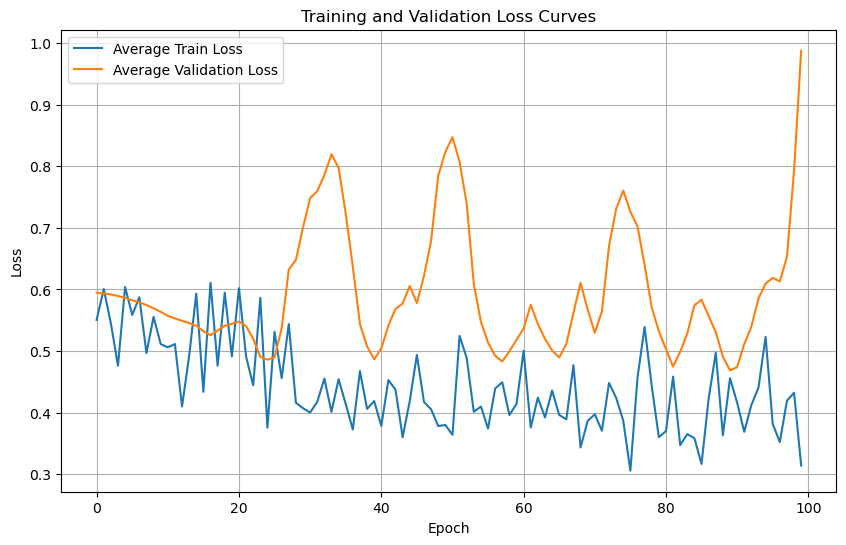

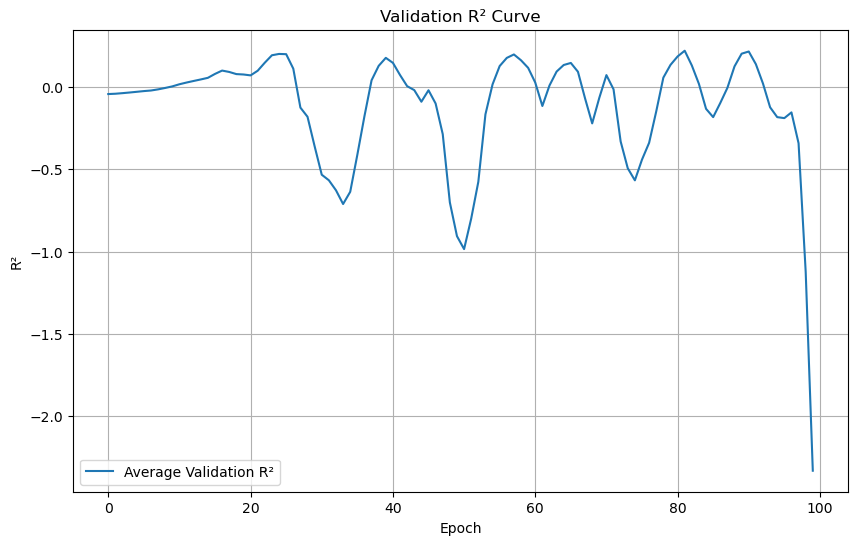

Time: 19.04 seconds
R²: 0.2765


In [ ]:
# the pain and suffering of a mac user
device = "mps" if torch.backends.mps.is_available() else "cpu"

# small subset
subset = graph_dataset[:100]  

start = time.time()

results = KFoldCrossValidation(
    model_class=GNN,
    graph_dataset=subset,
    k=3,
    batch_size=64,
    epochs=100,
    hidden_dim=64,
    dropout=0.1,
    lr=1e-3,
    loss_type="smoothl1",
    beta=0.5,
    device=device,
    make_plots=True,
    verbose=False
)

end = time.time()

print(f"Time: {end - start:.2f} seconds")
print(f"R²: {results['mean_val_r2']:.4f}")

Now I am going to very roughly explore hyperparameter space. God save us all.

In [ ]:
# class GNNRegressor(BaseEstimator):
#     def __init__(
#         self,
#         hidden_dim=64,
#         lr=1e-3,
#         dropout=0.1,
#         batch_size=64,
#         beta=0.5,
#         epochs=15,
#         device="cpu"
#     ):
#         self.hidden_dim = hidden_dim
#         self.lr = lr
#         self.dropout = dropout
#         self.batch_size = batch_size
#         self.beta = beta
#         self.epochs = epochs
#         self.device = device
# 
#     def fit(self, X, y=None):
#         in_channels = X[0].x.shape[1]
#         edge_dim = X[0].edge_attr.shape[1]
#         out_dim = X[0].y.shape[1]
# 
#         self.model_ = GNN(
#             in_channels=in_channels,
#             edge_dim=edge_dim,
#             hidden_dim=self.hidden_dim,
#             out_dim=out_dim,
#             dropout=self.dropout
#         )
# 
#         self.trainer_ = Trainer(
#             model=self.model_,
#             lr=self.lr,
#             loss_type="smoothl1",
#             beta=self.beta,
#             device=self.device
#         )
# 
#         train_loader = DataLoader(X, batch_size=self.batch_size, shuffle=True)
# 
#         for _ in range(self.epochs):
#             self.trainer_.train_one_epoch(train_loader)
# 
#         return self
# 
#     def score(self, X, y=None):
#         val_loader = DataLoader(X, batch_size=self.batch_size, shuffle=False)
#         _, val_r2 = self.trainer_.evaluate(val_loader)
#         return val_r2
# 
# 
# from scipy.stats import loguniform, uniform
# 
# subset = graph_dataset[:1000]  
# 
# param_dist = {
#     "hidden_dim": [64, 80, 96, 112, 128, 144, 160],
#     "lr": loguniform(3e-4, 1e-3),
#     "dropout": uniform(0.0, 0.15),
#     "batch_size": [64, 128],
#     "beta": uniform(0.2, 0.5),
# }
# 
# search = HalvingRandomSearchCV(
#     estimator=GNNRegressor(device=device),
#     param_distributions=param_dist,
#     factor=2,
#     resource="epochs",
#     max_resources=20,
#     min_resources=5,
#     cv=3,
#     verbose=0,
#     refit=False,
#     random_state=67
# )
# 
# search.fit(subset)
# 
# # show results of hyperparameter search in df sorted by R² and then std dev of R² 
# df = pd.DataFrame(search.cv_results_)
# 
# df = df[[
#     "mean_test_score",
#     "std_test_score",
#     "param_hidden_dim",
#     "param_lr",
#     "param_dropout",
#     "param_batch_size",
#     "param_beta"
# ]].rename(columns={
#     "mean_test_score": "r2",
#     "std_test_score": "std",
#     "param_hidden_dim": "hidden_dim",
#     "param_lr": "lr",
#     "param_dropout": "dropout",
#     "param_batch_size": "batch_size",
#     "param_beta": "beta"
# })
# 
# df = df.sort_values(
#     by=["r2", "std"],
#     ascending=[False, True]
# ).reset_index(drop=True)
# 
# df

,r2,std,hidden_dim,lr,dropout,batch_size,beta
0,0.405500,0.046364,80,0.000447,0.142703,128,0.575712
1,0.299761,0.038575,80,0.000447,0.142703,128,0.575712
2,0.153331,0.243959,64,0.000907,0.022265,128,0.595165
3,0.131290,0.004044,80,0.000447,0.142703,128,0.575712
4,0.128690,0.072334,64,0.000907,0.022265,128,0.595165
5,0.100106,0.132593,160,0.000527,0.123197,64,0.223448
6,-0.455497,0.352836,64,0.000996,0.028176,64,0.357538
